# 02 · Do firms manipulate reported emissions? Eight tests, eight nulls

**What this notebook answers.** Three of my advisor's items:

> *"Comparing year-to-year growth rates rather than growth relative to the threshold
> could lead to more fruitful results."*

> *"We saw that firms within 5,000 units of the threshold seem to have emissions grow
> slightly less fast than firms away from the threshold."*

> *"Investigate the growth-rate bunching we saw today further — are certain sectors
> driving this? What happens if we shrink or grow the 'within 5,000' window?"*

## Why growth rates instead of levels

Notebook 01 killed the level-based tests: threshold-bound facilities are absent below
25,000, so there is no observed counterfactual density. **Growth-rate space fixes half
of this.** Condition on facilities that were *above* 25,000 last year — all of them are
observed — and ask how they moved. Both "crossed below" and "stayed above" are visible,
because a facility that crosses below still reports in the crossing year (and for the
next several years, under 98.2(i)).

## The eight tests

| # | test | where | result |
|---|---|---|---|
| 1 | level density at 25,000 | notebook 01, `f14` | null (ratio 0.96) |
| 2 | level density at 15,000 | notebook 01 | null |
| 3 | growth rates, near vs far (±5,000) | §1 | **not significant**, t = −0.69 |
| 4 | excess mass in the bin below zero gap | §3 | null at 25,000, **significant at placebos** |
| 5 | same, split by group | §3 | null at 25,000, significant at placebos |
| 6 | window & sector sensitivity | §4 | it is a **size** effect |
| 7 | dominated-region depression (Kleven–Waseem) | §5 | no hole |
| 8 | **state density at 25,000, both sides observed** | §6 | null, p = 0.63 / 0.85 |

⚠️ **Wording discipline, established in §6.** Power is finite. The correct claim is not
"there is no manipulation" but *"any discontinuity is smaller than this sample can
detect"* — with the detectable size stated.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

sys.path.insert(0, ".")
from ghgrp_load import load_cached, add_transitions

OUT = Path("output")
K, W = 25000, 5000
CUTOFFS = [(25000, "real threshold"), (40000, "placebo"), (60000, "placebo")]

de = load_cached()
de, d = add_transitions(de)
d["near"] = d.lag_em.between(K - W, K + W)

print(f"year-on-year transitions   {len(d):,}")
print(f"  within ±5,000 of 25,000  {d.near.sum():,}")
print(f"  outside                  {(~d.near).sum():,}")

GROUPS = [("all firms", d, "#7F7F7F"), ("within ±5,000", d[d.near], "#4C72B0"),
          ("outside ±5,000", d[~d.near], "#C44E52")]
display(pd.DataFrame({lab: s.growth.describe([.1, .25, .5, .75, .9])
                      for lab, s, _ in GROUPS}).T.round(3))

year-on-year transitions   84,863
  within ±5,000 of 25,000  9,320
  outside                  75,543


,count,mean,std,min,10%,25%,50%,75%,90%,max
all firms,84863.0,-0.034,0.600,-14.346,-0.368,-0.122,-0.004,0.093,0.289,13.531
"within ±5,000",9320.0,-0.037,0.545,-11.412,-0.359,-0.114,0.000,0.106,0.315,4.053
"outside ±5,000",75543.0,-0.033,0.607,-14.346,-0.369,-0.123,-0.004,0.092,0.285,13.531


## 1 · Test 3 — "firms near the threshold grow slightly less fast"

This was the observation from the meeting. It is worth testing carefully because it is
the kind of pattern that is easy to see and easy to misread.

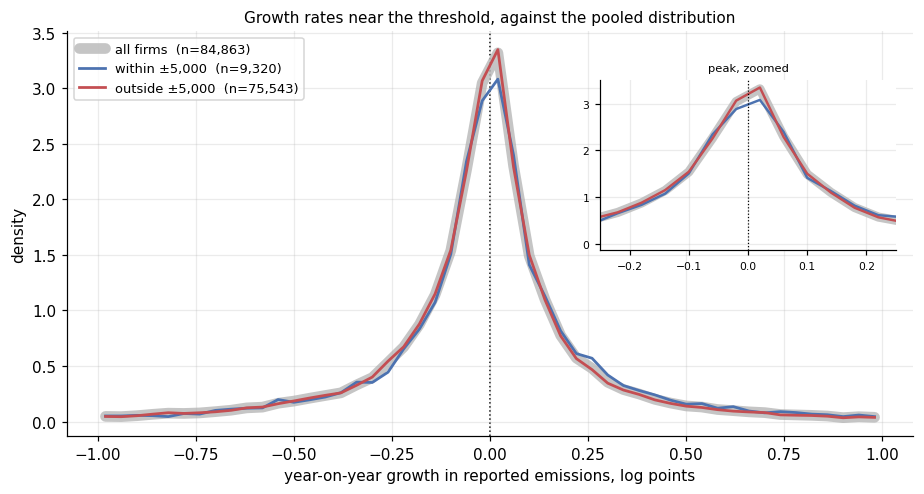

In [2]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
bins = np.arange(-1.0, 1.02, .04)
for lab, sub, col in GROUPS:
    s = sub.growth; s = s[(s >= -1) & (s <= 1)]
    h, e = np.histogram(s, bins=bins, density=True)
    if lab == "all firms":
        ax.plot(e[:-1] + .02, h, color="#BBBBBB", lw=7, alpha=.85, solid_capstyle="round",
                label=f"{lab}  (n={len(sub):,})", zorder=1)
    else:
        ax.plot(e[:-1] + .02, h, color=col, lw=1.8, label=f"{lab}  (n={len(sub):,})", zorder=3)
ax.axvline(0, color="k", ls=":", lw=1, zorder=0)
ax.set_xlabel("year-on-year growth in reported emissions, log points")
ax.set_ylabel("density"); ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("Growth rates near the threshold, against the pooled distribution", fontsize=10)
axi = ax.inset_axes([.63, .46, .35, .42])
for lab, sub, col in GROUPS:
    s = sub.growth; s = s[(s >= -1) & (s <= 1)]
    h, e = np.histogram(s, bins=bins, density=True)
    axi.plot(e[:-1] + .02, h, color="#BBBBBB" if lab == "all firms" else col,
             lw=6 if lab == "all firms" else 1.6, alpha=.85 if lab == "all firms" else 1)
axi.set_xlim(-.25, .25); axi.axvline(0, color="k", ls=":", lw=.8)
axi.tick_params(labelsize=7); axi.set_title("peak, zoomed", fontsize=7.5)
plt.tight_layout(); plt.savefig(OUT / "f12_growth_near_threshold.png", bbox_inches="tight"); plt.show()

In [3]:
A = d.loc[d.near, "growth"]; B = d.loc[~d.near, "growth"]
t = stats.ttest_ind(A, B, equal_var=False)
print(f"mean difference (near − far): {A.mean()-B.mean():+.4f}   t = {t.statistic:.2f}   p = {t.pvalue:.3f}")
print(f"sd:  near {A.std():.3f}   far {B.std():.3f}")
print(f"KS test p = {stats.ks_2samp(A, B).pvalue:.1e}\n")
q = pd.DataFrame({"near": A.quantile([.1, .25, .5, .75, .9]), "far": B.quantile([.1, .25, .5, .75, .9])})
q["difference"] = q.near - q.far
display(q.round(4))

mean difference (near − far): -0.0042   t = -0.69   p = 0.488
sd:  near 0.545   far 0.607
KS test p = 1.7e-05



,near,far,difference
0.10,-0.3595,-0.3686,0.0091
0.25,-0.1138,-0.1230,0.0092
0.50,0.0000,-0.0045,0.0045
0.75,0.1063,0.0919,0.0144
0.90,0.3147,0.2855,0.0292


### ★ Correction to record: the observation does not survive a test

- mean difference **−0.0042, t = −0.69, p = 0.49** → **not significant**
- but **every decile from p10 to p90 is higher for the near group** (+0.009 to +0.029)
- KS p = 1.7e-5 → the distributions genuinely differ, but in **shape**, not location

> **The right statement is: growth rates near the threshold are *narrower*
> (sd 0.545 vs 0.607), not *slower*.**

That is a different claim and it needs its own explanation. Three candidates:
(a) **composition** — facilities near the threshold differ in size and sector;
(b) **real behaviour** — the monitoring that comes with reporting reduces volatility;
(c) a mechanical regression-to-the-mean effect.

§4 tests (a) and finds it is the answer.

## 2 · The composition trap — an error I nearly published

The natural next test: among facilities above 25,000 last year, do threshold-bound
facilities cross *below* more often than always-covered ones? Manipulation predicts yes.

In [4]:
ab = d[d.lag_em > 25000].copy()
ab["r"] = np.log(ab.lag_em / 25000)
ab["y"] = np.log(ab.emissions / 25000)
ab["rbin"] = pd.cut(ab.r, [0, .1, .25, .5, 1, 2, 10])

t_ = (ab.groupby(["rbin", "threshold_bound"], observed=True)
        .agg(n=("y", "size"), crossed=("y", lambda s: (s < 0).mean())).reset_index())
naive = pd.DataFrame({
    "n_always": t_.pivot(index="rbin", columns="threshold_bound", values="n")[False],
    "cross_always": t_.pivot(index="rbin", columns="threshold_bound", values="crossed")[False],
    "n_bound": t_.pivot(index="rbin", columns="threshold_bound", values="n")[True],
    "cross_bound": t_.pivot(index="rbin", columns="threshold_bound", values="crossed")[True]})
naive["diff"] = naive.cross_bound - naive.cross_always
display(naive.round(3))

,n_always,cross_always,n_bound,cross_bound,diff
rbin,,,,,
"(0.0, 0.1]",590,0.358,2459,0.354,-0.003
"(0.1, 0.25]",998,0.216,3967,0.179,-0.037
"(0.25, 0.5]",1777,0.122,6077,0.083,-0.038
"(0.5, 1.0]",4363,0.045,10771,0.034,-0.011
"(1.0, 2.0]",6615,0.019,13714,0.010,-0.009
"(2.0, 10.0]",12214,0.004,9397,0.004,-0.000


**Every bin is negative** — threshold-bound facilities cross *less* often than
always-covered ones, which is backwards from the manipulation prediction. Read
carelessly, this looks like evidence that threshold-bound facilities work to stay above
the line, e.g. from fear of scrutiny.

**It is composition.** Always-covered facilities are dominated by power plants, whose
annual output swings with dispatch:

In [5]:
print("growth-rate volatility by group:")
display(d.groupby("threshold_bound").growth.agg(["size", "mean", "std"]).round(3))

print("\nvolatility by subpart — always-covered is dominated by power generation (D):")
for sp in ["D", "HH", "H", "C", "W-PROC"]:
    s = d[d.subpart_set.map(lambda z: sp in z)].growth
    if len(s): print(f"  {sp:<8} n={len(s):>6,}   sd={s.std():.3f}")

share_D = d.loc[~d.threshold_bound, "subpart_set"].map(lambda z: "D" in z).mean()
print(f"\nshare of always-covered transitions involving subpart D: {share_D:.0%}")

growth-rate volatility by group:


,size,mean,std
threshold_bound,,,
False,31617,-0.029,0.612
True,53246,-0.036,0.593



volatility by subpart — always-covered is dominated by power generation (D):
  D        n=14,928   sd=0.764
  HH       n=15,064   sd=0.411
  H        n= 1,207   sd=0.479
  C        n=70,411   sd=0.609
  W-PROC   n= 5,365   sd=0.594

share of always-covered transitions involving subpart D: 47%


**Subpart D (power generation) has growth sd 0.764 against 0.593 for threshold-bound
facilities, and 47% of always-covered transitions involve subpart D.** A more volatile
group crosses any fixed line more often, whatever its incentives.

Condition on each facility's own growth volatility and the difference disappears:

In [6]:
vol = d.groupby("FacilityId").growth.std().rename("vol")
ab2 = ab.join(vol, on="FacilityId")
ab2["volq"] = pd.qcut(ab2.vol, 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
ab2["rbin"] = pd.cut(ab2.r, [0, .25, .5, 1, 10])

t2 = (ab2.groupby(["volq", "rbin", "threshold_bound"], observed=True)
        .agg(n=("y", "size"), cross=("y", lambda s: (s < 0).mean())).reset_index())
p_ = t2.pivot_table(index=["volq", "rbin"], columns="threshold_bound", values="cross")
n_ = t2.pivot_table(index=["volq", "rbin"], columns="threshold_bound", values="n")
res = pd.DataFrame({"n_always": n_[False], "n_bound": n_[True],
                    "cross_always": p_[False], "cross_bound": p_[True]})
res["diff"] = res.cross_bound - res.cross_always
display(res[res.n_always >= 30].round(3))

n_always  n_bound  cross_always  cross_bound   diff
volq    rbin                                                            
Q1 low  (0.0, 0.25]     312.0   1942.0         0.122        0.116 -0.006
        (0.25, 0.5]     448.0   1744.0         0.002        0.001 -0.002
        (0.5, 1.0]     1127.0   3116.0         0.000        0.000  0.000
        (1.0, 10.0]    2363.0   7128.0         0.000        0.000  0.000
Q2      (0.0, 0.25]     181.0   1608.0         0.199        0.238  0.039
        (0.25, 0.5]     275.0   1657.0         0.044        0.025 -0.018
        (0.5, 1.0]      542.0   2863.0         0.002        0.002 -0.000
        (1.0, 10.0]    4046.0   7011.0         0.000        0.000  0.000
Q3      (0.0, 0.25]     468.0   1382.0         0.269        0.280  0.011
        (0.25, 0.5]     482.0   1299.0         0.137        0.099 -0.038
        (0.5, 1.0]     1285.0   2459.0         0.016        0.016  0.000
        (1.0, 10.0]    6011.0   4802.0         0.000        0.000  0.000
Q4 high (0.0, 0.25]     626.0   1401.0         0.363        0.396  0.034
        (0.25, 0.5]     572.0   1335.0         0.240        0.243  0.003
        (0.5, 1.0]     1406.0   2290.0         0.123        0.140  0.017
        (1.0, 10.0]    6396.0   4143.0         0.027        0.040  0.013

> **Methodological rule this produced, which I now apply everywhere:**
> when a result surprises me, check in this order —
> **my own code → sample composition → institutional rules → behaviour.**
> I had it backwards twice (the 2015 exit spike, this crossing differential) and both
> times the answer was in the first two steps.

## 3 · Tests 4 and 5 — excess mass just below the cutoff

The statistic: take the gap $g = \log(E_t / c)$ for facilities that started within
±5,000 of cutoff $c$, and compare the count in the bin immediately **below** zero to the
average of its two neighbours. Manipulation piles mass exactly there.

This is **my own construction, not Chetty–Kleven**. It is deliberately simple, and
because it is homemade the placebo cutoffs do real work: they calibrate the statistic's
own bias rather than testing a hypothesis.

In [7]:
BW = 0.05
BINS = np.arange(-0.6, 0.6 + BW, BW)          # zero falls exactly on an edge
I0 = int(np.round((0 - BINS[0]) / BW)) - 1    # bin immediately BELOW zero
print(f"bin below zero spans [{BINS[I0]:+.2f}, {BINS[I0+1]:+.2f})  <- must end at 0.00")


def gap_hist(sub, cut):
    gap = np.log(sub.emissions / cut).values
    gap = gap[(gap >= BINS[0]) & (gap <= BINS[-1])]
    return gap, np.histogram(gap, bins=BINS)[0].astype(float)


def excess(c):
    nb = (c[I0 - 1] + c[I0 + 1]) / 2
    return (c[I0] - nb) / nb if nb > 0 else np.nan, c[I0], nb


def boot_ci(c, n, B=2000, seed=0):
    rng = np.random.default_rng(seed); p = c / c.sum()
    f = lambda cc: (cc[I0] - (cc[I0-1] + cc[I0+1]) / 2) / max((cc[I0-1] + cc[I0+1]) / 2, 1e-9)
    return np.percentile([f(rng.multinomial(n, p).astype(float)) for _ in range(B)], [2.5, 97.5])


rows = []
for cut, kind in CUTOFFS:
    sub = d[d.lag_em.between(cut - W, cut + W)]
    gap, c = gap_hist(sub, cut); ex, b, nb = excess(c)
    rows.append(dict(cutoff=f"{cut:,}", kind=kind, n=len(gap),
                     crossed_below=f"{(gap < 0).mean():.1%}",
                     bin_below=int(b), neighbour_avg=round(nb, 1), excess=round(ex, 3)))
display(pd.DataFrame(rows))

bin below zero spans [-0.05, +0.00)  <- must end at 0.00


,cutoff,kind,n,crossed_below,bin_below,neighbour_avg,excess
0,"25,000",real threshold,8385,42.5%,765,765.5,-0.001
1,"40,000",placebo,7197,52.7%,896,815.0,0.099
2,"60,000",placebo,4449,51.7%,636,545.0,0.167


⚠️ **A bug worth recording.** The index of "the bin below zero" was originally found with
`np.searchsorted(bins, 0) - 1`. Floating-point error in `np.arange` put zero a hair
below an edge, so that picked the *wrong bin* — and would have reported the answer
backwards. It is now computed by integer arithmetic on a grid where zero is exactly an
edge, with a printed self-check above. **This class of error is invisible unless you
test for it, and it flips conclusions.**

### Test 5 — split by group

This split is the one that speaks to my advisor's "bunching exists across sectors" note: it
asks whether the excess sits with the group that has an incentive.

In [8]:
rows = []
for cut, kind in CUTOFFS:
    sub = d[d.lag_em.between(cut - W, cut + W)]
    for tb, lab in [(True, "threshold-bound"), (False, "always-covered")]:
        s = sub[sub.threshold_bound == tb]
        if len(s) < 150: continue
        gap, c = gap_hist(s, cut); ex, b, nb = excess(c)
        lo, hi = boot_ci(c, len(gap))
        rows.append(dict(cutoff=f"{cut:,}", kind=kind, group=lab, n=len(gap),
                         excess=round(ex, 3), ci_lo=round(lo, 3), ci_hi=round(hi, 3),
                         significant=bool(lo > 0 or hi < 0)))
G = pd.DataFrame(rows); G.to_csv(OUT / "t6_gap_by_group.csv", index=False)
display(G)

,cutoff,kind,group,n,excess,ci_lo,ci_hi,significant
0,"25,000",real threshold,threshold-bound,6564,-0.041,-0.131,0.057,False
1,"25,000",real threshold,always-covered,1821,0.176,-0.018,0.440,False
2,"40,000",placebo,threshold-bound,5533,0.107,0.002,0.208,True
3,"40,000",placebo,always-covered,1664,0.069,-0.112,0.273,False
4,"60,000",placebo,threshold-bound,3140,0.136,0.012,0.278,True
5,"60,000",placebo,always-covered,1309,0.248,0.033,0.502,True


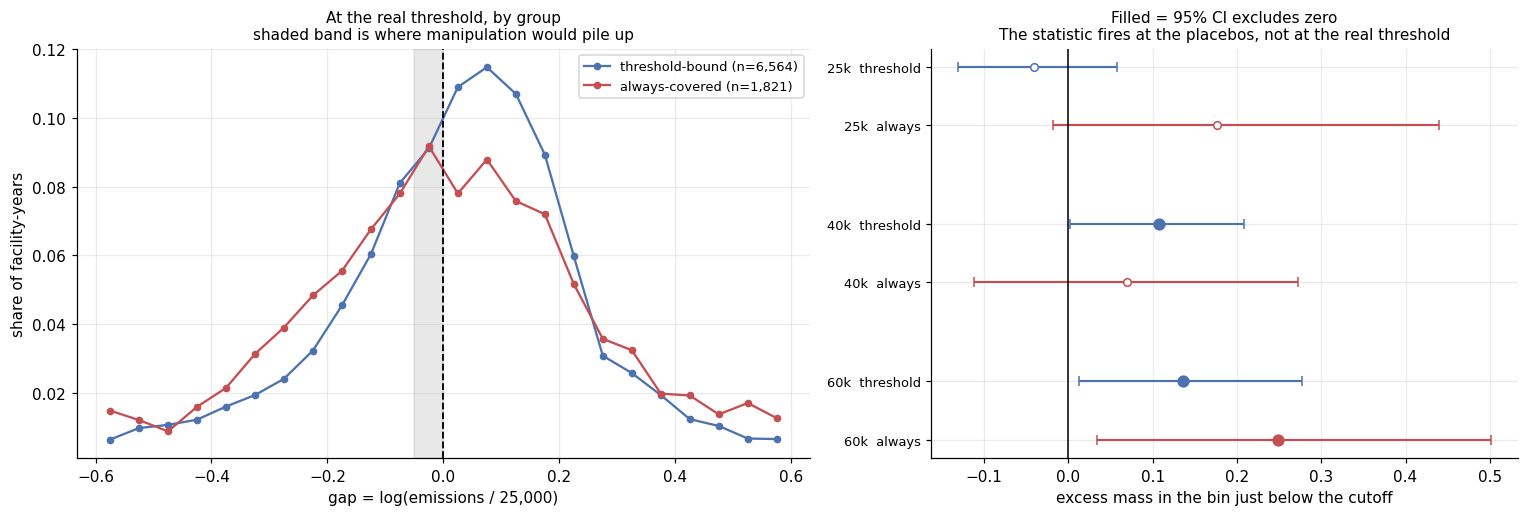

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})
sub = d[d.lag_em.between(K - W, K + W)]
for tb, lab, col in [(True, "threshold-bound", "#4C72B0"), (False, "always-covered", "#C44E52")]:
    s = sub[sub.threshold_bound == tb]; gap, c = gap_hist(s, K)
    ax[0].plot(BINS[:-1] + BW / 2, c / c.sum(), "o-", ms=4, color=col, label=f"{lab} (n={len(gap):,})")
ax[0].axvspan(BINS[I0], BINS[I0 + 1], color="#999", alpha=.22, zorder=0)
ax[0].axvline(0, color="k", ls="--", lw=1.2)
ax[0].set_xlabel("gap = log(emissions / 25,000)"); ax[0].set_ylabel("share of facility-years")
ax[0].set_title("At the real threshold, by group\nshaded band is where manipulation would pile up",
                fontsize=10)
ax[0].legend(fontsize=8.5)

pos = 0; yt = []; yl = []
for cut, kind in CUTOFFS:
    s2 = d[d.lag_em.between(cut - W, cut + W)]
    for tb, lab, col in [(True, "threshold-bound", "#4C72B0"), (False, "always-covered", "#C44E52")]:
        x = s2[s2.threshold_bound == tb]
        if len(x) < 150: pos += 1; continue
        gap, c = gap_hist(x, cut); e_, _, _ = excess(c); lo, hi = boot_ci(c, len(gap))
        sig = (lo > 0 or hi < 0)
        ax[1].errorbar(e_, pos, xerr=[[e_ - lo], [hi - e_]], fmt="o", ms=7 if sig else 5,
                       color=col, mfc=col if sig else "white", capsize=3, lw=1.4)
        yt.append(pos); yl.append(f"{cut//1000}k  {lab.split('-')[0]}"); pos += 1
    pos += .7
ax[1].axvline(0, color="k", lw=1)
ax[1].set_yticks(yt); ax[1].set_yticklabels(yl, fontsize=8.5); ax[1].invert_yaxis()
ax[1].set_xlabel("excess mass in the bin just below the cutoff")
ax[1].set_title("Filled = 95% CI excludes zero\nThe statistic fires at the placebos, not at the real threshold",
                fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "f15_gap_by_group.png", bbox_inches="tight"); plt.show()

### ★ Verdict — and this is stronger than "we failed to find anything"

| cutoff | group | excess | 95% CI | significant |
|---|---|---|---|---|
| **25,000 real** | threshold-bound | **−0.041** | [−0.131, +0.057] | no |
| **25,000 real** | always-covered | +0.176 | [−0.018, +0.440] | no |
| 40,000 placebo | threshold-bound | +0.107 | [+0.002, +0.208] | **yes** |
| 60,000 placebo | threshold-bound | +0.136 | [+0.012, +0.278] | **yes** |
| 60,000 placebo | always-covered | +0.248 | [+0.033, +0.502] | **yes** |

> **The statistic is significantly positive at two cutoffs where no rule exists, and
> insignificant — and negative — at the one where a rule does.**

This is not a power problem. The statistic demonstrably fires; it just does not fire
where the incentive is. The placebos are calibrating its own upward bias, and the real
threshold does not clear that noise line. At 25,000 the threshold-bound group is
**0.217 lower** than always-covered — the opposite sign from manipulation.

## 4 · Test 6 — window and sector sensitivity (my advisor's direct question)

> *"What happens if we shrink or grow the 'within 5,000' window? Are certain sectors
> driving this?"*

The right way to answer is to run the identical exercise at the placebo cutoffs. If the
narrowing appears there too, it is a property of firm size, not of the rule.

In [10]:
rows = []
for cut, _ in CUTOFFS:
    for w in [2000, 5000, 10000, 20000]:
        near = d[d.lag_em.between(cut - w, cut + w)]; far = d[~d.lag_em.between(cut - w, cut + w)]
        if len(near) < 300: continue
        rows.append(dict(cutoff=cut, window=w, n_near=len(near),
                         sd_near=round(near.growth.std(), 3), sd_far=round(far.growth.std(), 3),
                         ratio=round(near.growth.std() / far.growth.std(), 3)))
Wd = pd.DataFrame(rows); Wd.to_csv(OUT / "t7_window_sensitivity.csv", index=False)
display(Wd.pivot(index="window", columns="cutoff", values="ratio")
          .rename(columns={25000: "25,000 (REAL)", 40000: "40,000 (placebo)", 60000: "60,000 (placebo)"}))

cutoff,"25,000 (REAL)","40,000 (placebo)","60,000 (placebo)"
window,,,
2000,0.893,0.770,0.692
5000,0.899,0.825,0.679
10000,0.918,0.790,0.777
20000,0.997,0.772,0.717


In [11]:
d["szbin"] = pd.cut(d.lag_em, [0, 1e4, 2.5e4, 5e4, 1e5, 2.5e5, 1e6, 1e10],
                    labels=["<10k", "10–25k", "25–50k", "50–100k", "100–250k", "250k–1M", ">1M"])
sz = d.groupby("szbin", observed=True).growth.agg(["size", "std"]).round(3)
sz.columns = ["n", "sd of growth"]; display(sz)

rows = []
for cut, _ in CUTOFFS:
    near = d[d.lag_em.between(cut - W, cut + W)]
    for n3, sub in near.groupby("naics3"):
        far = d[(d.naics3 == n3) & ~d.lag_em.between(cut - W, cut + W)]
        if len(sub) < 200 or len(far) < 200: continue
        rows.append(dict(cutoff=cut, naics3=n3, n_near=len(sub),
                         ratio=round(sub.growth.std() / far.growth.std(), 3)))
S = pd.DataFrame(rows); S.to_csv(OUT / "t8_sector_breakdown.csv", index=False)
display(S.pivot(index="naics3", columns="cutoff", values="ratio"))
for cut, _ in CUTOFFS:
    s = S[S.cutoff == cut]
    print(f"{cut:>7,}: {(s.ratio<1).sum()}/{len(s)} sectors narrower inside the window")

,n,sd of growth
szbin,,
<10k,4095,1.495
10–25k,7826,0.681
25–50k,21966,0.510
50–100k,19004,0.464
100–250k,13704,0.519
250k–1M,10356,0.491
>1M,7912,0.400


cutoff,25000,40000,60000
naics3,,,
211,0.998,0.941,0.776
212,1.060,NaN,NaN
221,0.928,0.994,0.942
311,0.954,1.139,0.407
322,0.862,NaN,NaN
325,1.074,0.695,0.434
327,1.421,1.143,0.597
331,0.725,0.672,0.702
336,0.977,NaN,NaN


 25,000: 7/12 sectors narrower inside the window
 40,000: 6/8 sectors narrower inside the window
 60,000: 8/8 sectors narrower inside the window


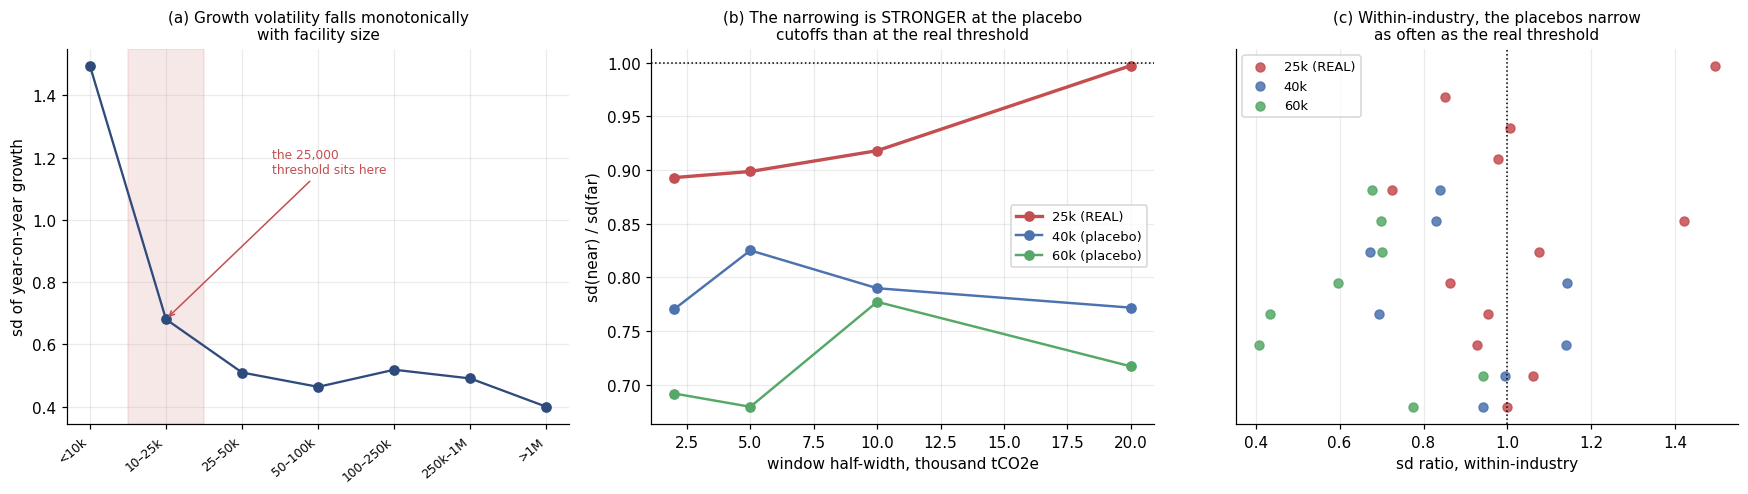

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
cols = {25000: "#C44E52", 40000: "#4C72B0", 60000: "#55A868"}

ax[0].plot(range(len(sz)), sz["sd of growth"], "o-", color="#2F4B7C", ms=6)
ax[0].set_xticks(range(len(sz))); ax[0].set_xticklabels(sz.index, rotation=40, ha="right", fontsize=8)
ax[0].axvspan(.5, 1.5, color="#C44E52", alpha=.13)
ax[0].annotate("the 25,000\nthreshold sits here", (1, sz["sd of growth"].iloc[1]),
               xytext=(2.4, 1.15), fontsize=8, color="#C44E52",
               arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1))
ax[0].set_ylabel("sd of year-on-year growth")
ax[0].set_title("(a) Growth volatility falls monotonically\nwith facility size", fontsize=10)

for cut, c in cols.items():
    r = [d[d.lag_em.between(cut - w, cut + w)].growth.std() / d[~d.lag_em.between(cut - w, cut + w)].growth.std()
         for w in [2000, 5000, 10000, 20000]]
    ax[1].plot([2, 5, 10, 20], r, "o-", color=c, ms=6, lw=2.2 if cut == 25000 else 1.6,
               label=f"{cut//1000}k" + (" (REAL)" if cut == 25000 else " (placebo)"))
ax[1].axhline(1, color="k", ls=":", lw=1); ax[1].legend(fontsize=8.5)
ax[1].set_xlabel("window half-width, thousand tCO2e"); ax[1].set_ylabel("sd(near) / sd(far)")
ax[1].set_title("(b) The narrowing is STRONGER at the placebo\ncutoffs than at the real threshold",
                fontsize=10)

for cut, c in cols.items():
    s = S[S.cutoff == cut]
    ax[2].scatter(s.ratio, range(len(s)), color=c, s=34, alpha=.85,
                  label=f"{cut//1000}k" + (" (REAL)" if cut == 25000 else ""))
ax[2].axvline(1, color="k", ls=":", lw=1); ax[2].set_yticks([]); ax[2].legend(fontsize=8.5)
ax[2].set_xlabel("sd ratio, within-industry")
ax[2].set_title("(c) Within-industry, the placebos narrow\nas often as the real threshold", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "f16_window_sensitivity.png", bbox_inches="tight"); plt.show()

### ★ Verdict — it is a size effect

1. the placebo cutoffs narrow **more** than the real one (0.68–0.83 vs 0.89–1.00 —
   every placebo ratio is below every real-threshold ratio);
2. growth volatility falls **monotonically** with facility size (1.50 → 0.40), and
   25,000 sits on the steepest part of that gradient;
3. within-industry, the real threshold narrows in 7 of 12 sectors — the 60,000 placebo
   narrows in **8 of 8**.

> **This line is closed.** It closes only the "growth rates differ near the threshold"
> observation, not the main argument.

## 5 · Test 7 — the dominated region (Kleven–Waseem)

If reporting is a notch, there is a band just above 25,000 where a facility would be
strictly better off abating down to the threshold: the abatement costs less than the
reporting burden it avoids. Under frictionless optimisation that band should be
**empty**. Its emptiness identifies the size of frictions.

Its width is (annual reporting burden) / (marginal abatement cost). With EPA's own
burden figure of \$7,654 per reporter per year (notebook 03, §1) the region is a few
hundred tonnes wide — narrow, but the data resolve single tonnes.

In [13]:
BURDEN = 7654.0
lv = de.loc[de.threshold_bound & de.emissions.between(15000, 35000), "emissions"]

rows = []
for mac in [10, 20, 50]:
    w = BURDEN / mac
    inside = lv.between(25000, 25000 + w).sum()          # the dominated region
    above = lv.between(25000 + w, 25000 + 2 * w).sum()   # equal-width band just beyond it
    rows.append(dict(mac=f"${mac}/t", width=round(w),
                     region=f"[25,000, {25000+w:,.0f})", n_inside=inside,
                     n_next_band=above, ratio=round(inside / max(above, 1), 3)))
display(pd.DataFrame(rows))
print("a real depression would put this ratio well below 1")

,mac,width,region,n_inside,n_next_band,ratio
0,$10/t,765,"[25,000, 25,765)",783,802,0.976
1,$20/t,383,"[25,000, 25,383)",387,396,0.977
2,$50/t,153,"[25,000, 25,153)",150,144,1.042


a real depression would put this ratio well below 1


**No depression at any plausible abatement cost.** The dominated region is populated at
essentially the same rate as the band immediately beyond it.

Under the Kleven–Waseem logic this means **frictions are large relative to the notch**.
That is consistent with everything else here, and it is itself part of the answer: the
reporting burden is small enough that it does not move facilities *even where moving
would strictly pay*.

⚠️ Caveat to state in the paper: the region below 25,000 is truncated, so this test uses
only bands **above** the cutoff. It compares the dominated region to its immediate
neighbour rather than to a fitted counterfactual density.

## 6 · Test 8 — state data, where **both sides of the cutoff are observed**

This is the test the federal data cannot support. **California (MRR) and Washington
(Ecology) require reporting from 10,000 tCO₂e.** The 10,000–25,000 band — invisible
federally — is fully observed in both.

| | facility-years | in 10,000–25,000 |
|---|---|---|
| California, 2011–2023 | 10,382 (1,039 facilities) | **2,774** |
| Washington, 2012–2024 | 2,167 (190 facilities) | **723** |

### ★★ And an institutional fact that changes what the null means

> **In both states the *reporting* threshold is 10,000, but the *third-party
> verification* threshold is 25,000** (WAC 173-441-085; CA MRR).

Third-party verification — hiring an accredited verifier, site visit, document review —
is **far more expensive than reporting**. So 25,000 is a real and *costly* line in these
states, and a null there is stronger than the federal null: even a much more expensive
threshold induces no manipulation.

⚠️ It cuts the other way too: had I *found* bunching at 25,000 in state data, I could
not have separated the federal reporting duty from the state verification duty. Since
there is none, the confound does not bite.

### Estimator

Two earlier attempts failed their own placebos (a linear log-density fit; then a
homemade scan). This uses the **Cattaneo–Jansson–Ma (2020, JASA)** local-polynomial
density estimator — data-driven bandwidth, bias correction, jackknife SEs — which is the
standard in the RD literature. Code lives in `06_rddensity_state.py`.

In [14]:
import subprocess
print(subprocess.run([sys.executable, "06_rddensity_state.py"],
                     capture_output=True, text=True).stdout)

sample  cutoff         spec  n_left  n_right  rel_jump       t     p   sig  mde_rel  bad_fit
    CA   25000 unrestricted     682      392    -0.137  -0.477 0.633 False    0.801    False
    CA   25000   restricted     682      392    -0.256  -2.731 0.006  True    0.263    False
    CA   15000 unrestricted    1251      841    -0.141  -0.722 0.470 False    0.547    False
    CA   15000   restricted    1251      841    -0.355  -6.079 0.000  True    0.164    False
    CA   20000 unrestricted     841      682     0.837   2.106 0.035  True    1.112    False
    CA   20000   restricted     841      682     0.166   1.697 0.090 False    0.274    False
    CA   30000 unrestricted     392      296     0.084   0.295 0.768 False    0.797    False
    CA   30000   restricted     392      296    -0.046  -0.313 0.754 False    0.413    False
    CA   35000 unrestricted     296      292    -0.058  -0.230 0.818 False    0.704    False
    CA   35000   restricted     296      292     0.323   1.978 0.048  

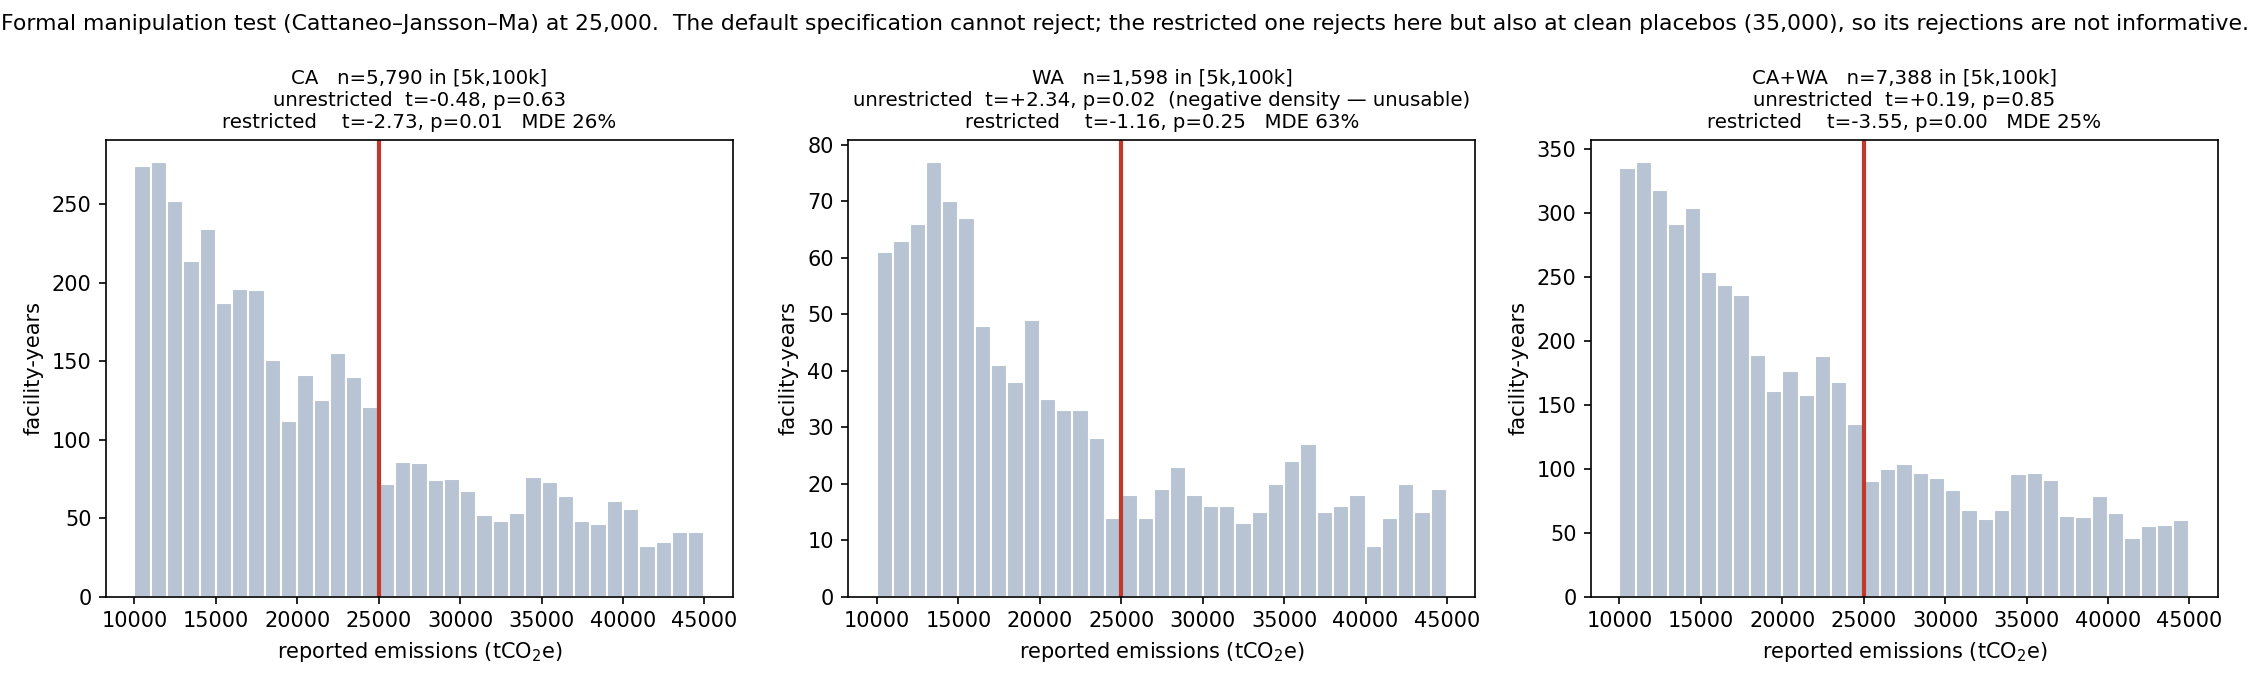

In [15]:
from IPython.display import Image, display as disp
disp(Image(filename=str(OUT / "f20_rddensity.png")))

### ★ Verdict — and the power caveat that must go in the paper

| sample | n in window | t at 25,000 | p |
|---|---|---|---|
| California | 5,790 | −0.48 | **0.63** |
| **CA + WA** | **7,388** | **+0.19** | **0.85** |

In the pooled sample **|t| at the real threshold is the smallest of all six cutoffs
tested.**

Two things to flag honestly:

1. **Washington's default fit is unusable** — it returns a *negative* density on the
   left, which is impossible; 143 left-side observations cannot support a local
   quadratic. Every stable alternative (restricted fit, p = 1, fixed bandwidth) is
   insignificant and flips sign. The table marks it `bad_fit`.
2. **The restricted specification does reject at 25,000** (p = 0.006) — **but it also
   rejects at 35,000, a clean placebo** (p = 0.048), and at 15,000 even harder
   (t = −10.4). Rejections that appear everywhere carry no information; this is the same
   failure mode as my two homemade tests, now confirmed with a standard estimator.

> **Minimum detectable effect (80% power, 5% level): 80–85% of the local density under
> the default specification, 25% under the restricted one.**

So the defensible sentence for the paper is:

> *Any density discontinuity at the federal threshold is smaller than 7,388 state
> facility-years can detect — bounded above at roughly 25–85% of the local density
> depending on specification.*

Not *"there is no manipulation"*.

## 7 · Power, stated directly

How much bunching would the federal growth-rate test have caught? Inject a known share
of mass into the bin below zero and re-run.

In [16]:
R_LO, R_HI, WIN = 0.10, 0.34, 0.50
BINS2 = np.arange(-WIN, WIN + 0.04, 0.04)
I02 = int(np.round((0 - BINS2[0]) / 0.04)) - 1
x = d.assign(r=np.log(d.lag_em / 25000), y=np.log(d.emissions / 25000))
s = x[(x.r > R_LO) & (x.r < R_HI) & x.threshold_bound].y
s = s[(s >= -WIN) & (s <= WIN)]
c0 = np.histogram(s, bins=BINS2)[0].astype(float); N = len(s)

f = lambda cc: (cc[I02] - (cc[I02-1] + cc[I02+1]) / 2) / max((cc[I02-1] + cc[I02+1]) / 2, 1e-9)
rng = np.random.default_rng(0); p = c0 / c0.sum()
null = np.array([f(rng.multinomial(N, p).astype(float)) for _ in range(4000)])
crit = np.nanpercentile(null, 95)
print(f"n = {N:,} | null sd = {np.nanstd(null):.3f} | one-sided 95% critical value = {crit:+.3f}")
print(f"observed = {f(c0):+.3f}\n")
print(f"{'injected share':>15}{'excess':>10}{'power':>8}")
for frac in [.005, .0075, .01, .02, .03]:
    pp = p.copy(); pp[I02] += frac; pp = pp / pp.sum()
    sims = np.array([f(rng.multinomial(int(N * (1 + frac)), pp).astype(float)) for _ in range(1200)])
    print(f"{frac:>14.2%}{np.median(sims):>+10.3f}{np.mean(sims>crit):>8.0%}")

n = 5,387 | null sd = 0.097 | one-sided 95% critical value = +0.078
observed = -0.088

 injected share    excess   power
         0.50%    +0.101     59%
         0.75%    +0.195     84%
         1.00%    +0.290     97%
         2.00%    +0.666    100%
         3.00%    +1.050    100%


With n = 5,387 in the band, the null standard deviation is 0.097 and the one-sided 95%
critical value is +0.078. The observed statistic is **−0.088**.

| injected share | median excess | power |
|---|---|---|
| 0.50% | +0.101 | 59% |
| **0.75%** | **+0.195** | **84%** |
| 1.00% | +0.290 | 97% |
| 2.00% | +0.666 | 100% |

> **80% power arrives at about 0.75% of the sample — roughly 40 facility-years bunching.**
> Manipulation of that size would have been detected. It was not.

---
## Summary — the eight nulls

| # | test | statistic | verdict |
|---|---|---|---|
| 1 | level density, 25,000 | ratio 0.96 | null |
| 2 | level density, 15,000 | ratio 0.97 | null |
| 3 | growth near vs far | t = −0.69, p = 0.49 | null (narrower, not slower) |
| 4 | excess mass, pooled | −0.041 | null |
| 5 | excess mass, by group | CI [−0.131, +0.057] | null; **placebos significant** |
| 6 | window / sector sensitivity | placebo ratios lower | size effect |
| 7 | dominated region | ratio ≈ 1 at every MAC | no hole → large frictions |
| 8 | **state density, both sides observed** | p = 0.63 / 0.85 | null, MDE 25–85% |

> **Firms subject to the disclosure threshold do not appear to manipulate reported
> emissions to avoid it — to the precision these data allow.**

### → Continue in **03_exit_and_cost**

If firms do not manipulate, does that mean disclosure is costless? No — and notebook 03
shows the opposite, using the one margin where behaviour *is* clearly visible: the
98.2(i) off-ramp. The two facts together produce a two-sided bound on the private cost
of disclosure.